In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/DataScience/Datasets/titanic.csv")

print(df.columns.tolist())

df.drop(columns=[col for col in df.columns
                 if col not in ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Embarked']],
        inplace=True)


print(df.columns.tolist())

print(df.head())

df.shape


['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Embarked']
   Survived  Pclass     Sex   Age  SibSp Embarked
0         0       3    male  22.0      1        S
1         1       1  female  38.0      1        C
2         1       3  female  26.0      0        S
3         1       1  female  35.0      1        S
4         0       3    male  35.0      0        S


(891, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Embarked  889 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 41.9+ KB


In [ ]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df[['Sex']].head(10)


,Sex
0,0
1,1
2,1
3,1
4,0
5,0
6,0
7,0
8,1
9,1


In [ ]:
df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

print(df[['Embarked']].head(15))

print(df['Embarked'].value_counts(dropna=False))

    Embarked
0        2.0
1        0.0
2        2.0
3        2.0
4        2.0
5        1.0
6        2.0
7        2.0
8        2.0
9        0.0
10       2.0
11       2.0
12       2.0
13       2.0
14       2.0
Embarked
2.0    644
0.0    168
1.0     77
NaN      2
Name: count, dtype: int64


In [ ]:
ean_age = df['Age'].mean()

df['Age'].fillna(mean_age, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Embarked  889 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 41.9 KB


/tmp/ipython-input-1744374202.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(mean_age, inplace=True)


In [ ]:
df = df.dropna(subset=['Embarked'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    int64  
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Embarked  889 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 48.6 KB


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

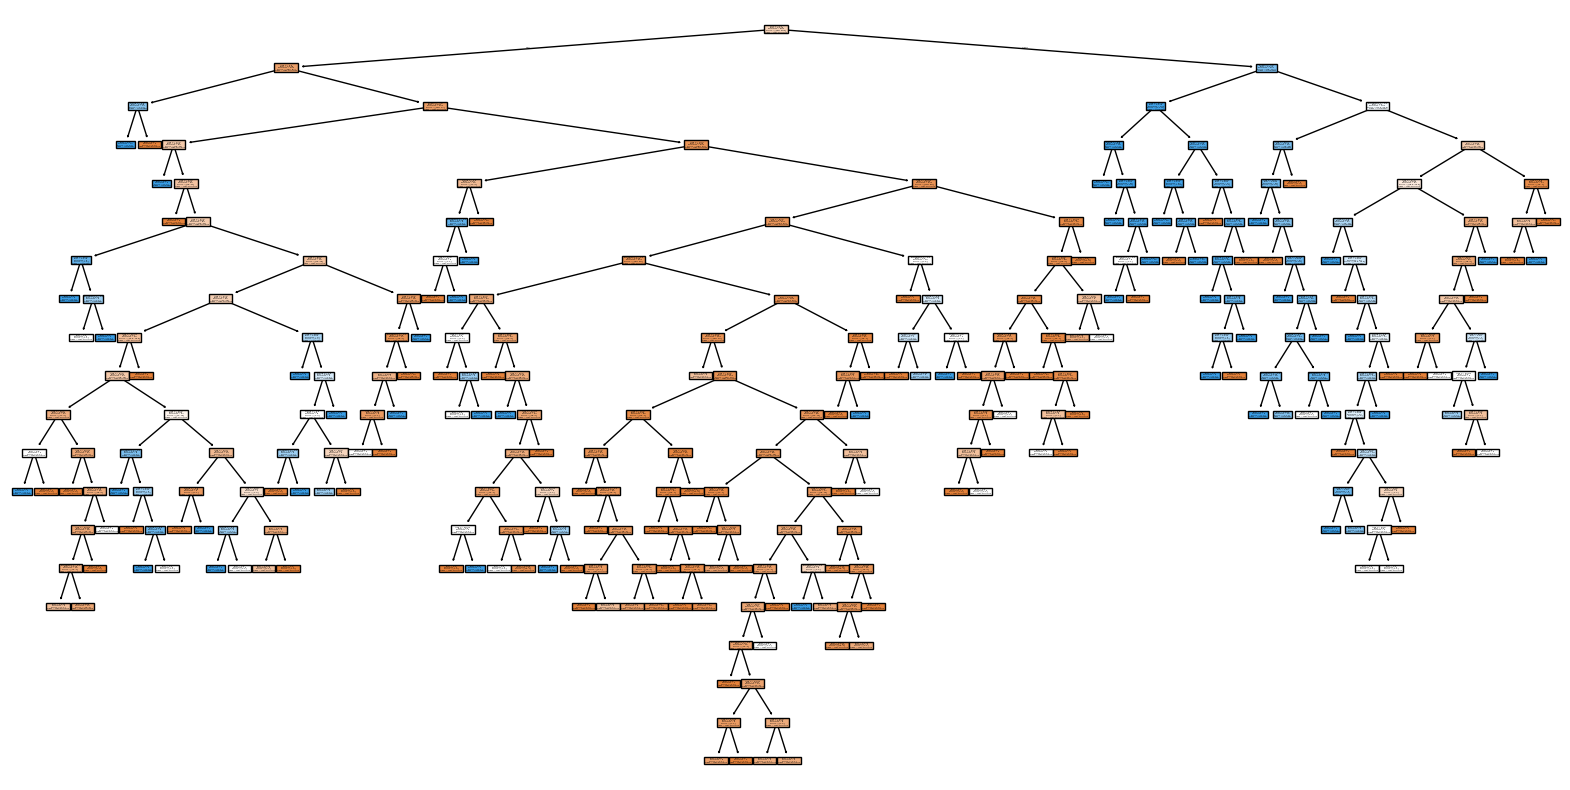

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=["Not Survived", "Survived"], filled=True)
plt.show()

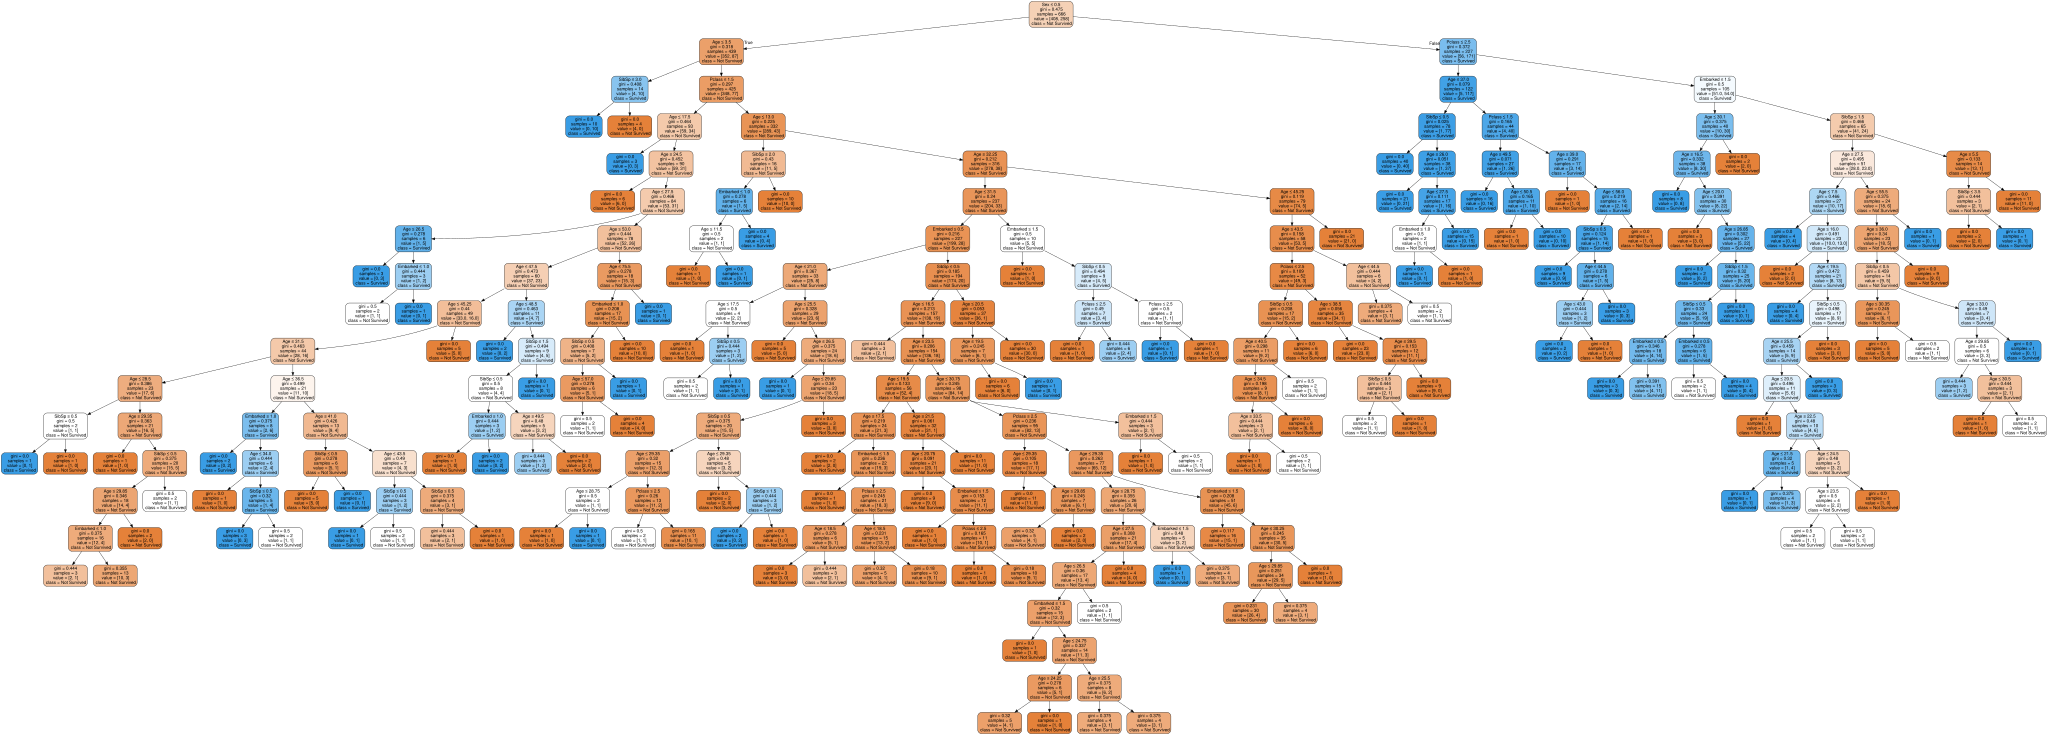

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(model, out_file=None,
                           feature_names=X.columns,
                           class_names=['Not Survived', 'Survived'],
                           filled=True, rounded=True,
                           special_characters=True)

graph = graphviz.Source(dot_data)
graph.format = 'pdf'
graph.render("titanic_decision_tree")
graph


In [ ]:
import pandas as pd

# Copy X_test dataframe
df_titanic_predict = X_test.copy()

# Add prediction results
df_titanic_predict['predicted_class'] = model.predict(X_test)
df_titanic_predict['actual_class'] = y_test

# Map target values (0,1) -> Target names
target_names = {
  0: "Not Survived",
  1: "Survived"
}
df_titanic_predict['predicted_class'] = df_titanic_predict['predicted_class'].map(target_names)
df_titanic_predict['actual_class'] = df_titanic_predict['actual_class'].map(target_names)

# แสดงผลตัวอย่าง 10 แถวแรก
print(df_titanic_predict.head(10))


     Pclass  Sex   Age  SibSp  Embarked predicted_class  actual_class
281       3    0  28.0      0       2.0    Not Survived  Not Survived
435       1    1  14.0      1       2.0        Survived      Survived
39        3    1  14.0      1       0.0        Survived      Survived
418       2    0  30.0      0       2.0    Not Survived  Not Survived
585       1    1  18.0      0       2.0        Survived      Survived
804       3    0  27.0      0       2.0    Not Survived      Survived
343       2    0  25.0      0       2.0    Not Survived  Not Survived
836       3    0  21.0      0       2.0    Not Survived  Not Survived
581       1    1  39.0      1       0.0        Survived      Survived
537       1    1  30.0      0       0.0        Survived      Survived


In [ ]:
from sklearn import metrics

print(metrics.classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       141
           1       0.73      0.77      0.75        82

    accuracy                           0.81       223
   macro avg       0.80      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223



In [ ]:

metrics.confusion_matrix(y_test, model.predict(X_test))


array([[118,  23],
       [ 19,  63]])

In [ ]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
acc

0.8116591928251121